In [ ]:
# checking all files present
import os
print(os.listdir())

['requisitionparser.ipynb', 'HM-Order_David_Lee.pdf', 'venv311']


Using AWS Textract to analyze requisition information:
1. extract key-value pairs with "FORMS" featuretype
2. extract medical exams with "TABLES" featuretype
3. extract signature (if it's present or not) with "SIGNATURE" featuretype

In [228]:
import boto3
import json

requisition_path = "HM-Order_David_Lee.pdf"

# connect to aws textract
client = boto3.client("textract", region_name="us-east-1")

# read raw bytes from the pdf
with open(requisition_path, "rb") as f:
    requisition_bytes = f.read()

# analyze document with textract 
response = client.analyze_document(
    Document={"Bytes": requisition_bytes},
    FeatureTypes=["FORMS", "TABLES", "SIGNATURES"] # want to get key-value pairs, the checked exams, and signature
)

In [229]:
for block in response["Blocks"]:
    if block["BlockType"] == "SIGNATURE":
        print(f"Signature found with {int(block['Confidence'])}% confidence")

Signature found with 81% confidence


In [230]:
for block in response["Blocks"]:
    if block["BlockType"] == "TABLE":
        print(f"Table found with {int(block['Confidence'])}% confidence")

Table found with 83% confidence
Table found with 89% confidence
Table found with 98% confidence
Table found with 82% confidence


In [231]:
# using dict to organize id, block
block_map = {}
for block in response["Blocks"]:
    block_map[block["Id"]] = block

In [232]:
# helper functions

# returns text from a specific block
def get_text(block, block_map):
    text = ""
    if "Relationships" in block:
        for rel in block["Relationships"]:
            if rel["Type"] == "CHILD":
                for child_id in rel["Ids"]:
                    word = block_map[child_id]
                    if word["BlockType"] == "WORD":
                        text += word["Text"] + " "
                    elif word["BlockType"] == "SELECTION_ELEMENT":
                        if word["SelectionStatus"] == "SELECTED":
                            text += "[X]"
    return text.strip()


# returns value block corresponding to its paired key block
def find_value_block(key_block, block_map):
    for rel in key_block.get("Relationships", []):
        if rel["Type"] == "VALUE":
            for value_id in rel["Ids"]:
                return block_map[value_id]
    return None

In [ ]:
tables = [b for b in response["Blocks"] if b["BlockType"] == "TABLE"]

checked_exams = []

for table in tables:
    # Get all cells for this table
    cell_ids = []
    for rel in table.get("Relationships", []):
        if rel["Type"] == "CHILD":
            cell_ids.extend(rel["Ids"])
    
    cells = [block_map[id] for id in cell_ids if block_map[id]["BlockType"] == "CELL"]
    
    # Group cells by row
    rows = {}
    for cell in cells:
        row_idx = cell["RowIndex"]
        col_idx = cell["ColumnIndex"]
        text = get_text(cell, block_map)
        if row_idx not in rows:
            rows[row_idx] = {}
        rows[row_idx][col_idx] = text
    
    # Find rows where Col 1 is [X] and append to checked_exams
    for row_idx, cols in rows.items():
        if cols.get(1) == "[X]":
            checked_exams.append({
                "cpt_code": cols.get(2),
                "exam_name": cols.get(3),
            })

print("Checked exams found:")
for exam in checked_exams:
    print(exam)

Checked exams found:
{'cpt_code': '74176', 'exam_name': 'CT ABDOMEN & PELVIS W/O CONTRAST'}


In [235]:
# assembling key-value pairs
key_value_pairs = {}

for block in response["Blocks"]:
    if block["BlockType"] == "KEY_VALUE_SET" and "KEY" in block["EntityTypes"]:
        
        key = get_text(block, block_map)
        
        value_block = find_value_block(block, block_map)
        value = get_text(value_block, block_map) if value_block else ""
        
        key_value_pairs[key] = value

In [236]:
# building output structure for key-value pairs
structure = {
    "patient" : {
        "name": key_value_pairs.get("Patient Name (Last, First):"),
        "dob": key_value_pairs.get("DOB:"),
        "gender": key_value_pairs.get("Gender:"), 
        "height": key_value_pairs.get("Height:"),
        "weight": key_value_pairs.get("Weight:"),
    },
    "insurance": {
        "provider": key_value_pairs.get("Insurance:"),
        "id": key_value_pairs.get("Insurance ID#:"),
        "group": key_value_pairs.get("Insurance Group #:"),
        "subscriber_name_dob": key_value_pairs.get("Insurance Subscriber Name & DOB:"),
        "relationship_to_patient": key_value_pairs.get("Relationship to Patient:"),
    },
    "clinical": {
        "dx_code": key_value_pairs.get("Dx Code:"),
        "reason_for_exam": key_value_pairs.get("Reason for Exam:"),
        "pregnant": key_value_pairs.get("Pregnant:"),
        "diabetes": key_value_pairs.get("Diabetes:"),
        "creatinine_or_egfr": key_value_pairs.get("Creatinine or EGFR"),
        "dialysis": key_value_pairs.get("Dialysis:"),
        "dialysis_dates": key_value_pairs.get("Tues Thurs Sat"),  # Textract picks up the options row
        "picc_ports_midline": key_value_pairs.get("Specify Type:"),
    },
    "physician": {
        "name": key_value_pairs.get("Physician Name:"),
        "npi": key_value_pairs.get("Physician NPI:"),
        "phone": key_value_pairs.get("Physician's Phone #:"),
        "fax": key_value_pairs.get("Physician's Fax #:"),
        "signature": key_value_pairs.get("Physician Signature:"),
        "date_of_order": key_value_pairs.get("Date & Time of Order:"),
    },
    "location": {
        "preferred_location": key_value_pairs.get("Select patient's preferred location (exam may not be offered at preferred location):"),
        "hmh": key_value_pairs.get("HMH"),
        "spring_branch": key_value_pairs.get("Spring Branch"),
        "pearland": key_value_pairs.get("Pearland"),
        "bellaire": key_value_pairs.get("Bellaire"),
        "from_facility": key_value_pairs.get("Is the pt coming from a facility? Y / N"),
    },
    "previous_imaging": {
        "previous_related_imaging": key_value_pairs.get("Previous related imaging:"),
        "if_yes_location": key_value_pairs.get("Yes, select location:"),
    },
    "scheduling": {
        "phone": key_value_pairs.get("SCHEDULING PHONE"),
        "hours": key_value_pairs.get("SCHEDULING DEPT HOURS"),
        "fax": key_value_pairs.get("SCHEDULING FAX"),
        "additional_scripts_email": key_value_pairs.get("FOR ADDITIONAL SCRIPTS, Email"),
    },
    "special_instructions": key_value_pairs.get("OTHER PROCEDURES / SPECIAL INSTRUCTIONS"),
}


In [237]:
# Build a lookup of checked CPT codes from the table parser
checked_cpt_codes = {exam["cpt_code"] for exam in checked_exams}

# adding exams to the structure
structure["exams_ordered"] = {
    "CT": {
        "CT_BRAIN_WO_CONTRAST": {"cpt_code": "70450", "checked": "70450" in checked_cpt_codes},
        "CT_ORBITS_SELA_EAR_FOSA_WO_CONTRAST": {"cpt_code": "70480", "checked": "70480" in checked_cpt_codes},
        "CT_ORBITS_SELA_EAR_FOSA_W_CONTRAST": {"cpt_code": "70481", "checked": "70481" in checked_cpt_codes},
        "CT_ORBITS_SELA_EAR_FOSA_WWO_CONTRAST": {"cpt_code": "70482", "checked": "70482" in checked_cpt_codes},
        "CT_SINUSES_MAXILLOFACIAL_WO_CONTRAST": {"cpt_code": "70486", "checked": "70486" in checked_cpt_codes},
        "CT_NECK_SOFT_TISSUE_W_CONTRAST": {"cpt_code": "70491", "checked": "70491" in checked_cpt_codes},
        "CTA_HEAD_WWO_CONTRAST": {"cpt_code": "70496", "checked": "70496" in checked_cpt_codes},
        "CTA_NECK_WWO_CONTRAST": {"cpt_code": "70498", "checked": "70498" in checked_cpt_codes},
        "CT_CHEST_WO_CONTRAST": {"cpt_code": "71250", "checked": "71250" in checked_cpt_codes},
        "CT_CHEST_W_CONTRAST": {"cpt_code": "71260", "checked": "71260" in checked_cpt_codes},
        "CTA_CHEST_NONCORONARY_WWO_CONTRAST": {"cpt_code": "71275", "checked": "71275" in checked_cpt_codes},
        "CT_CERVICAL_SPINE_WO_CONTRAST": {"cpt_code": "72125", "checked": "72125" in checked_cpt_codes},
        "CT_CERVICAL_SPINE_W_CONTRAST": {"cpt_code": "72126", "checked": "72126" in checked_cpt_codes},
        "CT_THORACIC_SPINE_WO_CONTRAST": {"cpt_code": "72128", "checked": "72128" in checked_cpt_codes},
        "CT_THORACIC_SPINE_W_CONTRAST": {"cpt_code": "72129", "checked": "72129" in checked_cpt_codes},
        "CT_LUMBAR_SPINE_WO_CONTRAST": {"cpt_code": "72131", "checked": "72131" in checked_cpt_codes},
        "CT_LUM_SPINE_W_CONTRAST": {"cpt_code": "72132", "checked": "72132" in checked_cpt_codes},
        "CT_PELVIS_WO_CONTRAST": {"cpt_code": "72192", "checked": "72192" in checked_cpt_codes},
        "CT_UPPER_EXTREMITY_WO_CONTRAST": {"cpt_code": "73200", "checked": "73200" in checked_cpt_codes, "laterality": None},
        "CTA_UPPER_EXTREMITY_WWO_CONTRAST": {"cpt_code": "73206", "checked": "73206" in checked_cpt_codes, "laterality": None},
        "CT_LOWER_EXTREMITY_WO_CONTRAST": {"cpt_code": "73700", "checked": "73700" in checked_cpt_codes, "laterality": None},
        "CTA_LOWER_EXT_WWO_CONTRAST": {"cpt_code": "73706", "checked": "73706" in checked_cpt_codes, "laterality": None},
        "CT_ABDOMEN_WO_CONTRAST": {"cpt_code": "74150", "checked": "74150" in checked_cpt_codes},
        "CT_ABDOMEN_W_CONTRAST": {"cpt_code": "74160", "checked": "74160" in checked_cpt_codes},
        "CT_ABDOMEN_WWO_CONTRAST": {"cpt_code": "74170", "checked": "74170" in checked_cpt_codes},
        "CTA_ABD_PELVIS_WWO_CONTRAST": {"cpt_code": "74174", "checked": "74174" in checked_cpt_codes},
        "CTA_ABDOMEN_WWO_CONTRAST": {"cpt_code": "74175", "checked": "74175" in checked_cpt_codes},
        "CT_ABDOMEN_PELVIS_WO_CONTRAST": {"cpt_code": "74176", "checked": "74176" in checked_cpt_codes},
        "CT_ABDOMEN_PELVIS_W_CONTRAST": {"cpt_code": "74177", "checked": "74177" in checked_cpt_codes},
        "CT_ABDOMEN_PELVIS_WWO_CONTRAST": {"cpt_code": "74178", "checked": "74178" in checked_cpt_codes},
    },
    "MRI": {
        "MRI_TEMPOROMANDIBULAR_JOINTS": {"cpt_code": "70336", "checked": "70336" in checked_cpt_codes},
        "MRI_FACE_NECK_ORBITS_WO_CONTRAST": {"cpt_code": "70540", "checked": "70540" in checked_cpt_codes},
        "MRI_FACE_NECK_ORBITS_WWO_CONTRAST": {"cpt_code": "70543", "checked": "70543" in checked_cpt_codes},
        "MRA_HEAD_WO_CONTRAST": {"cpt_code": "70544", "checked": "70544" in checked_cpt_codes},
        "MRA_NECK_WO_CONTRAST": {"cpt_code": "70547", "checked": "70547" in checked_cpt_codes},
        "MRI_BRAIN_IACS_PITUITARY_WO_CONTRAST": {"cpt_code": "70551", "checked": "70551" in checked_cpt_codes},
        "MRI_BRAIN_IACS_PITUITARY_WWO_CONTRAST": {"cpt_code": "70553", "checked": "70553" in checked_cpt_codes},
        "MRI_CHEST_WO_CONTRAST": {"cpt_code": "71550", "checked": "71550" in checked_cpt_codes},
        "MRI_CHEST_WWO_CONTRAST": {"cpt_code": "71552", "checked": "71552" in checked_cpt_codes},
        "MRI_CERVICAL_SPINE_WO_CONTRAST": {"cpt_code": "72141", "checked": "72141" in checked_cpt_codes},
        "MRI_THORACIC_SPINE_WO_CONTRAST": {"cpt_code": "72146", "checked": "72146" in checked_cpt_codes},
        "MRI_LUMBAR_SPINE_WO_CONTRAST": {"cpt_code": "72148", "checked": "72148" in checked_cpt_codes},
        "MRI_CERVICAL_SPINE_WWO_CONTRAST": {"cpt_code": "72156", "checked": "72156" in checked_cpt_codes},
        "MRI_SPINE_THORACIC_WWO_CONTRAST": {"cpt_code": "72157", "checked": "72157" in checked_cpt_codes},
        "MRI_LUMBAR_SPINE_WWO_CONTRAST": {"cpt_code": "72158", "checked": "72158" in checked_cpt_codes},
        "MRI_PELVIS_WO_CONTRAST": {"cpt_code": "72195", "checked": "72195" in checked_cpt_codes},
        "MRI_PELVIS_WWO_CONTRAST": {"cpt_code": "72197", "checked": "72197" in checked_cpt_codes},
        "MRI_UPPER_EXTREMITY_WO_CONTRAST": {"cpt_code": "73218", "checked": "73218" in checked_cpt_codes, "laterality": None},
        "MRI_UPPER_EXTREMITY_WWO_CONTRAST": {"cpt_code": "73220", "checked": "73220" in checked_cpt_codes, "laterality": None},
        "MRI_UPPER_EXTR_JOINT_WO_CONTRAST": {"cpt_code": "73221", "checked": "73221" in checked_cpt_codes, "laterality": None},
        "MRI_UPPER_EXTREMITY_JOINT_W_CONTRAST": {"cpt_code": "73222", "checked": "73222" in checked_cpt_codes, "laterality": None},
        "MRI_ELBOW_W_IA_GAD": {"cpt_code": "73222", "checked": "73222" in checked_cpt_codes, "laterality": None},
        "MRI_LOWER_EXTREMITY_NON_JOINT_WO_CONTRAST": {"cpt_code": "73718", "checked": "73718" in checked_cpt_codes, "laterality": None},
        "MRI_LOWER_EXTREMITY_WWO_CONTRAST": {"cpt_code": "73720", "checked": "73720" in checked_cpt_codes, "laterality": None},
        "MRI_LOWER_EXTR_JOINT_WO_CONTRAST": {"cpt_code": "73721", "checked": "73721" in checked_cpt_codes, "laterality": None},
        "MRI_LOWER_EXT_JOINT_W_CONTRAST": {"cpt_code": "73722", "checked": "73722" in checked_cpt_codes, "laterality": None},
        "MRI_LOWER_EXT_JOINT_WWO_CONTRAST": {"cpt_code": "73723", "checked": "73723" in checked_cpt_codes, "laterality": None},
        "MRI_ABDOMEN_WO_CONTRAST": {"cpt_code": "74181", "checked": "74181" in checked_cpt_codes},
        "MRI_ABDOMEN_WWO_CONTRAST": {"cpt_code": "74183", "checked": "74183" in checked_cpt_codes},
        "MRI_BONE_MARROW": {"cpt_code": "77084", "checked": "77084" in checked_cpt_codes},
    },
    "ULTRASOUND": {
        "ABDOMEN_COMPLETE": {"cpt_code": "76700", "checked": "76700" in checked_cpt_codes},
        "ABDOMINAL_DOPPLER": {"cpt_code": "97975", "checked": "97975" in checked_cpt_codes},
        "ABDOMINAL_AORTA": {"cpt_code": "76775", "checked": "76775" in checked_cpt_codes},
        "GALLBLADDER": {"cpt_code": "76705", "checked": "76705" in checked_cpt_codes},
        "ABDOMINAL_COMPLETE_AND_LIVER_ELASTOGRAPHY": {"cpt_code": "76891", "checked": "76891" in checked_cpt_codes},
        "THYROID": {"cpt_code": "76536", "checked": "76536" in checked_cpt_codes},
        "PANCREASE_TRANSPLANT": {"cpt_code": "76775", "checked": "76775" in checked_cpt_codes},
        "RENAL_NATIVE": {"cpt_code": "76770", "checked": "76770" in checked_cpt_codes},
        "RENAL_AND_RENAL_BLOOD_FLOW": {"cpt_code": "93975", "checked": "93975" in checked_cpt_codes},
        "RENAL_TRANSPLANT": {"cpt_code": "76776", "checked": "76776" in checked_cpt_codes},
        "BLADDER_PRE_POST_VOID": {"cpt_code": "76775", "checked": "76775" in checked_cpt_codes},
        "SCROTUM_TESTICULAR": {"cpt_code": "76870", "checked": "76870" in checked_cpt_codes},
        "PROSTATE": {"cpt_code": "76872", "checked": "76872" in checked_cpt_codes},
        "PELVIC_COMPLETE_TRANSVAGINAL_TRANSABDOMINAL": {"cpt_code": "76830", "checked": "76830" in checked_cpt_codes},
        "PELVIC_TRANSABDOMINAL_ONLY": {"cpt_code": "76856", "checked": "76856" in checked_cpt_codes},
        "PREGNANCY_UNDER_14_WKS_TRANSVAGINAL": {"cpt_code": "76801", "checked": "76801" in checked_cpt_codes},
        "PREGNANCY_OVER_14_WKS": {"cpt_code": "76805", "checked": "76805" in checked_cpt_codes},
        "DUPLEX_SCAN_EXTRACRANIAL_BILAT_CAROTID": {"cpt_code": "93880", "checked": "93880" in checked_cpt_codes},
        "ARTERIAL_DPLX_SCAN_LW_EXT_BIL": {"cpt_code": "93925", "checked": "93925" in checked_cpt_codes, "laterality": None},
        "ARTERIAL_DOPPLER_UNI": {"cpt_code": "93926", "checked": "93926" in checked_cpt_codes, "laterality": None},
        "VENOUS_DOPPLER_BILAT": {"cpt_code": "93970", "checked": "93970" in checked_cpt_codes, "laterality": None},
        "VENOUS_DOPPLER": {"cpt_code": "93971", "checked": "93971" in checked_cpt_codes, "laterality": None},
    },
    "XRAY": {
        "ABDOMEN_1_VIEW_KUB": {"cpt_code": "74018", "checked": "74018" in checked_cpt_codes},
        "ABDOMEN_2_VIEWS_FLAT_UPRIGHT": {"cpt_code": "74019", "checked": "74019" in checked_cpt_codes},
        "ABDOMEN_ACUTE_INCL_CHEST_PA_AP": {"cpt_code": "74022", "checked": "74022" in checked_cpt_codes},
        "ANKLE_3_VIEWS": {"cpt_code": "73610", "checked": "73610" in checked_cpt_codes, "laterality": None},
        "ARTHROGRAM_W_IA_GAD": {"cpt_code": "73040", "checked": "73040" in checked_cpt_codes, "laterality": None},
        "BONE_DENSITY_AXIAL_DEXA": {"cpt_code": "77080", "checked": "77080" in checked_cpt_codes},
        "BONE_DENSITY_PERIPHERAL": {"cpt_code": "77081", "checked": "77081" in checked_cpt_codes},
        "CERVICAL_SPINE_2_VIEWS": {"cpt_code": "72040", "checked": "72040" in checked_cpt_codes},
        "CERVICAL_SPINE_COMPLETE": {"cpt_code": "72050", "checked": "72050" in checked_cpt_codes},
        "CERVICAL_SPINE_COMPLETE_FLEX_EXT": {"cpt_code": "72052", "checked": "72052" in checked_cpt_codes},
        "CHEST_2_VIEWS": {"cpt_code": "71046", "checked": "71046" in checked_cpt_codes},
        "ELBOW_2_VIEWS": {"cpt_code": "73070", "checked": "73070" in checked_cpt_codes, "laterality": None},
        "ESOPHAGRAM_BARIUM_SWALLOW": {"cpt_code": "74221", "checked": "74221" in checked_cpt_codes},
        "FEMUR_2_VIEWS": {"cpt_code": "73552", "checked": "73552" in checked_cpt_codes, "laterality": None},
        "FOOT_3_VIEWS": {"cpt_code": "73630", "checked": "73630" in checked_cpt_codes, "laterality": None},
        "FOREARM_RADIUS_ULNA_2_VIEWS": {"cpt_code": "73090", "checked": "73090" in checked_cpt_codes, "laterality": None},
        "HAND_3_VIEWS": {"cpt_code": "73130", "checked": "73130" in checked_cpt_codes, "laterality": None},
        "HIP_2_VIEWS": {"cpt_code": "73502", "checked": "73502" in checked_cpt_codes, "laterality": None},
        "HIPS_BILATERAL_W_AP_PELVIS": {"cpt_code": "73522", "checked": "73522" in checked_cpt_codes},
        "HUMERUS_2_VIEWS": {"cpt_code": "73060", "checked": "73060" in checked_cpt_codes, "laterality": None},
        "KNEE_3_VIEWS": {"cpt_code": "73562", "checked": "73562" in checked_cpt_codes, "laterality": None},
        "LEG_TIBIA_FIBULA_2_VIEWS": {"cpt_code": "73590", "checked": "73590" in checked_cpt_codes, "laterality": None},
        "LUMBAR_SPINE_2_VIEWS": {"cpt_code": "72100", "checked": "72100" in checked_cpt_codes},
        "LUMBAR_SPINE_COMPLETE": {"cpt_code": "72110", "checked": "72110" in checked_cpt_codes},
        "LUMBAR_SPINE_COMPLETE_FLEX_EXT": {"cpt_code": "72114", "checked": "72114" in checked_cpt_codes},
        "NECK_SOFT_TISSUE": {"cpt_code": "70360", "checked": "70360" in checked_cpt_codes},
        "RIBS_UNILATERAL_2_VIEWS": {"cpt_code": "71100", "checked": "71100" in checked_cpt_codes, "laterality": None},
        "SHOULDER_2_VIEWS": {"cpt_code": "73030", "checked": "73030" in checked_cpt_codes, "laterality": None},
        "SPINE_ENTIRE_SCOLIOSIS": {"cpt_code": "72082", "checked": "72082" in checked_cpt_codes},
        "THORACIC_SPINE_3_VIEWS": {"cpt_code": "72072", "checked": "72072" in checked_cpt_codes},
        "UGI_W_AIR_HD_BA_SMALL_BOWEL": {"cpt_code": "74249", "checked": "74249" in checked_cpt_codes},
        "UPPER_GI_W_AIR_GLUC_HD_BARIUM": {"cpt_code": "74246", "checked": "74246" in checked_cpt_codes},
        "WRIST_3_VIEWS": {"cpt_code": "73110", "checked": "73110" in checked_cpt_codes, "laterality": None},
    }
}

In [238]:
# add signature results to structure
structure["physician"]["signature_present"] = any(
    b["BlockType"] == "SIGNATURE" for b in response["Blocks"]
)

In [243]:
def clean(obj):
    if isinstance(obj, dict):
        return {k: clean(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [clean(i) for i in obj]
    return obj if obj not in ("", " ", "Y/N") else None

In [244]:
structure = clean(structure)
print(json.dumps(structure, indent=2))

{
  "patient": {
    "name": "Lee, David",
    "dob": "02/18/1948",
    "gender": "M",
    "height": "5'9\"",
    "weight": "183lls."
  },
  "insurance": {
    "provider": "Medicare",
    "id": "(MED-618 3920",
    "group": "N/A",
    "subscriber_name_dob": null,
    "relationship_to_patient": null
  },
  "clinical": {
    "dx_code": "K57.30",
    "reason_for_exam": "diverticulitis, without abscess, follow up staging",
    "pregnant": null,
    "diabetes": null,
    "creatinine_or_egfr": null,
    "dialysis": null,
    "dialysis_dates": null,
    "picc_ports_midline": null
  },
  "physician": {
    "name": "Dr. amanda Foster",
    "npi": "1789013456",
    "phone": "(713)555-0501",
    "fax": "(713)555-0502",
    "signature": null,
    "date_of_order": "03/17/2026",
    "signature_present": true
  },
  "location": {
    "preferred_location": null,
    "hmh": null,
    "spring_branch": null,
    "pearland": null,
    "bellaire": null,
    "from_facility": null
  },
  "previous_imaging": 

Trying with CPT 73218 checked + laterality = R. Using LLM to find exam related information from the list of checked exams.

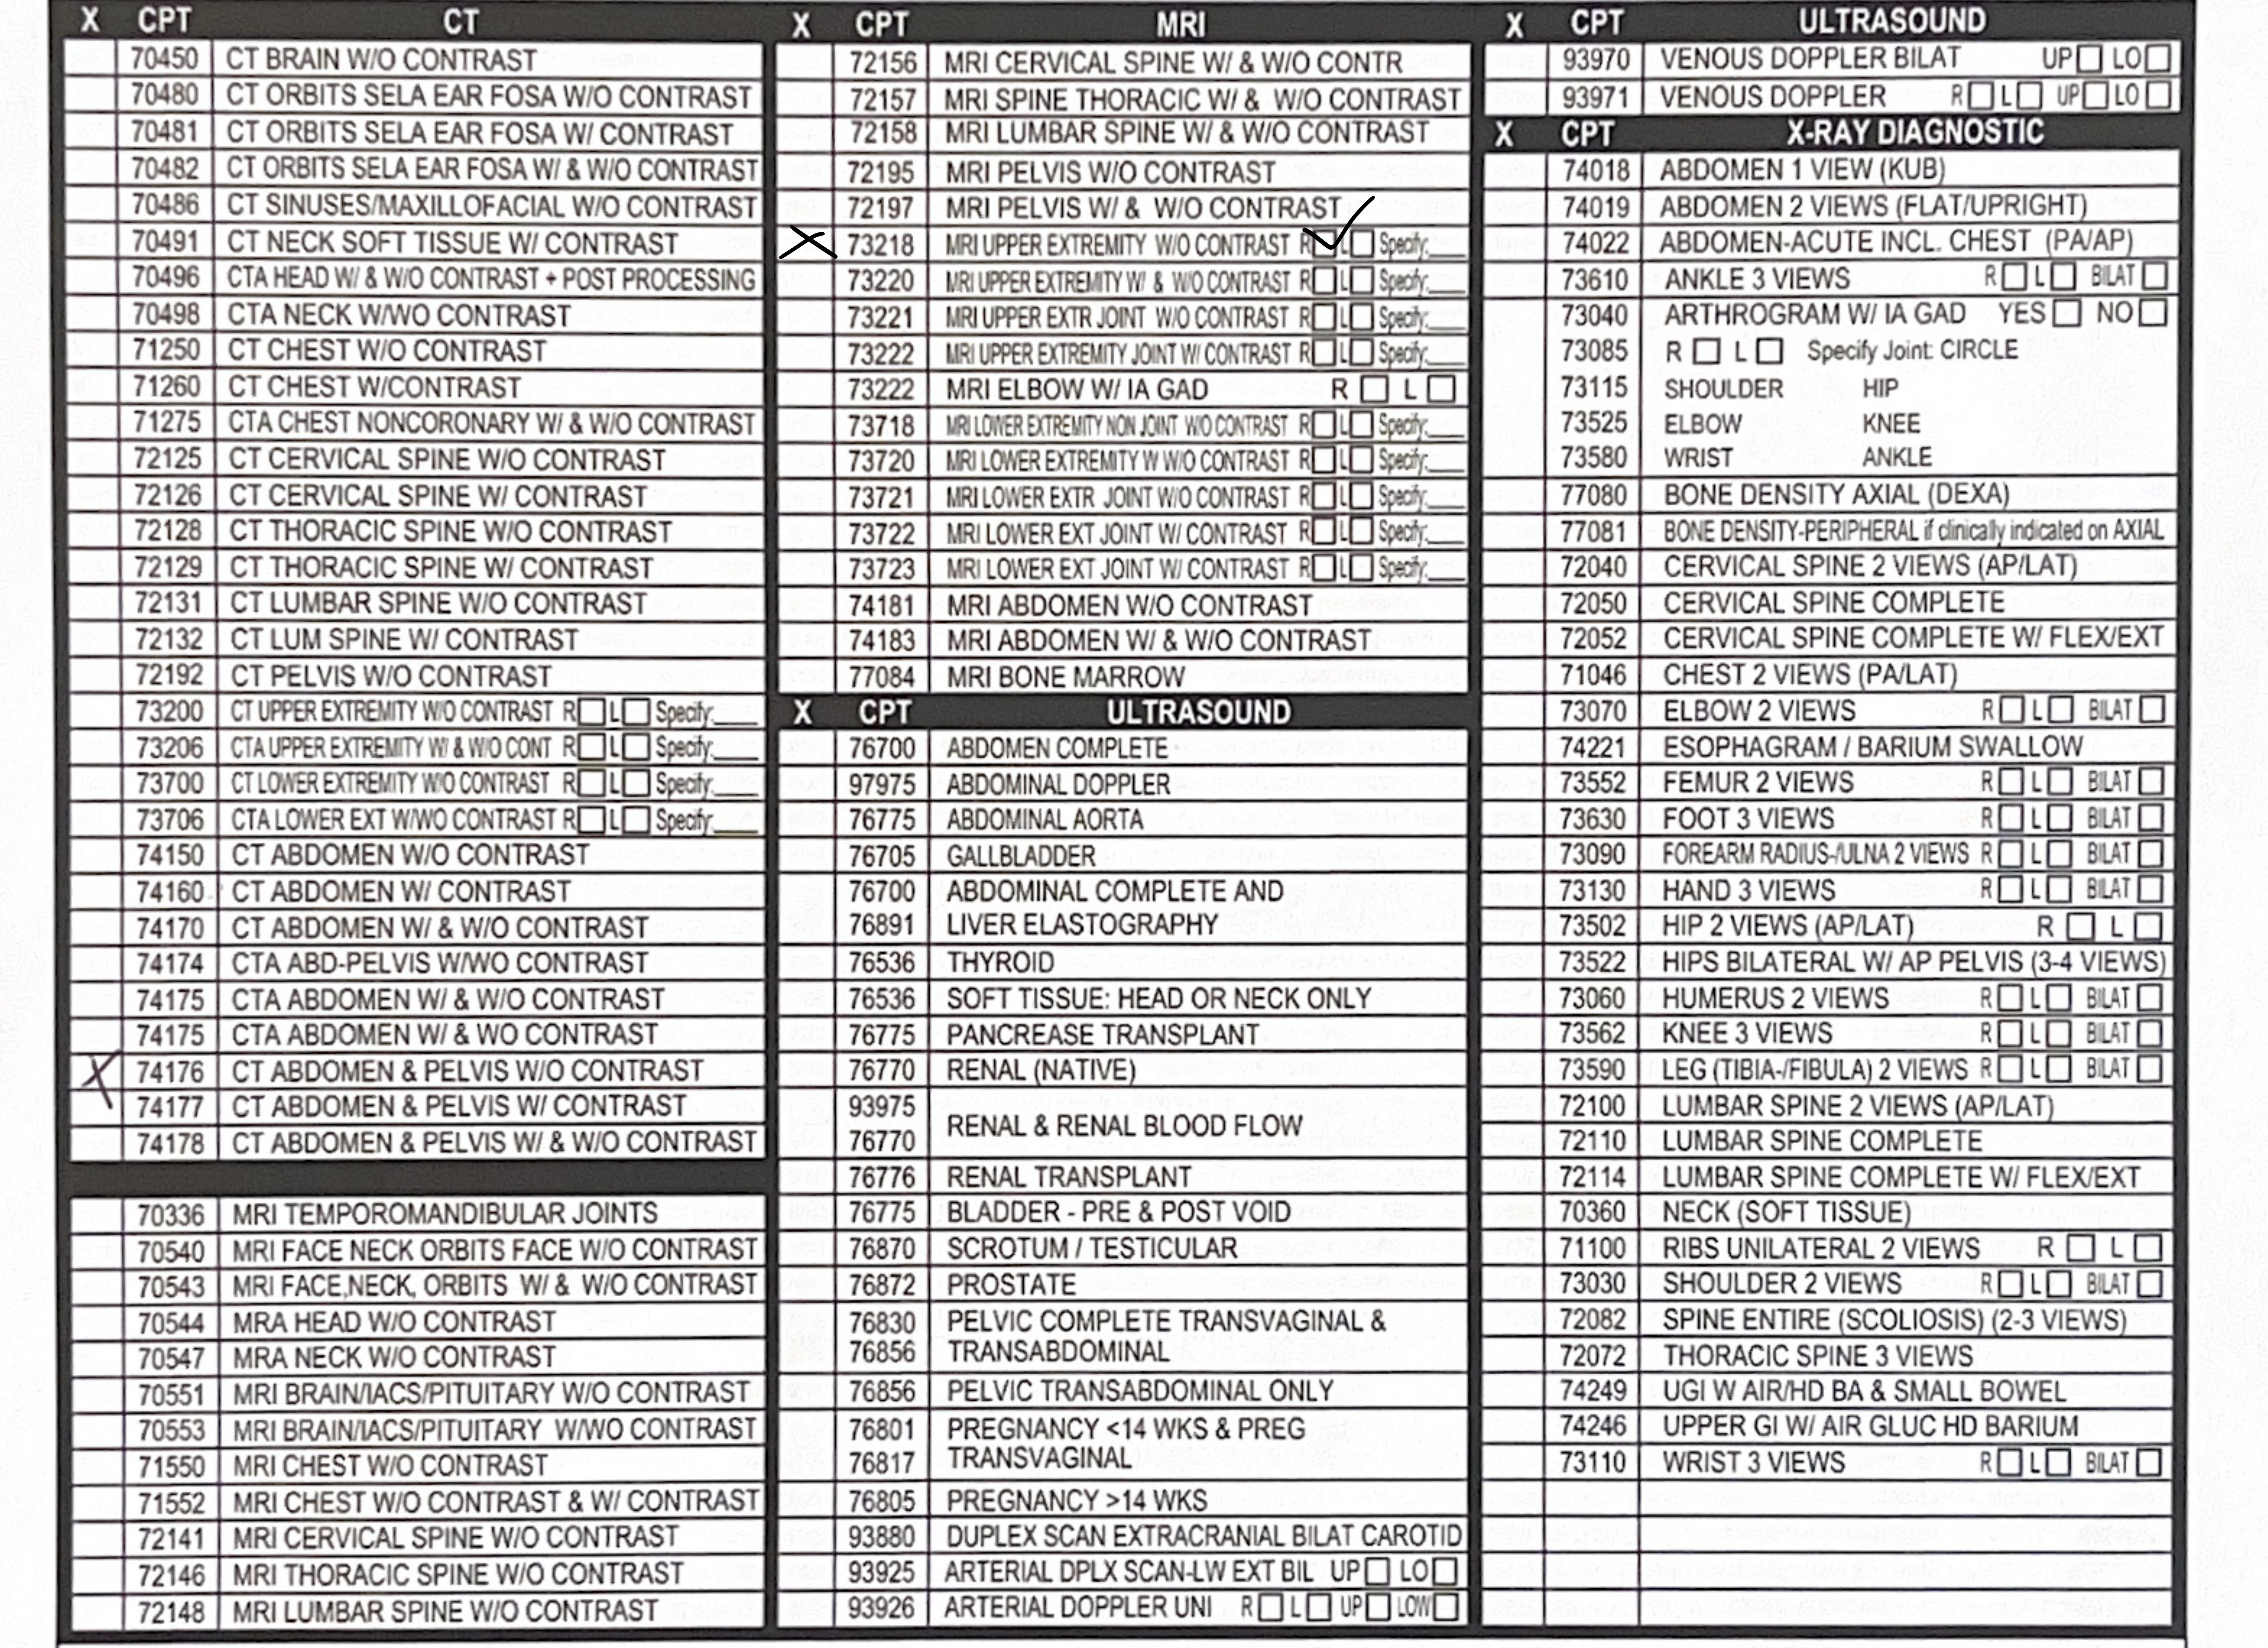

Image size: 6598.9 KB


In [220]:
import fitz  # pip install pymupdf
import base64

# Convert first page of PDF to base64 image
doc = fitz.open("HM-Order_David_Lee.pdf")
page = doc[0]

# Crop to just the table
# Coordinates are in points: (x0, y0, x1, y1)
rect = fitz.Rect(0, 620, 1569, 1760)
clip = page.get_pixmap(dpi=300, clip=rect)
img_bytes = clip.tobytes("jpeg")

from IPython.display import Image, display
display(Image(data=img_bytes))
print(f"Image size: {len(img_bytes) / 1024:.1f} KB")

img_base64 = base64.b64encode(img_bytes).decode("utf-8")

In [226]:
checked_exam_list = "\n".join(
    [f"- CPT {exam['cpt_code']}: {exam['exam_name']}" for exam in checked_exams]
)

prompt = f"""
You are extracting structured data from a cropped scanned medical imaging requisition form.

Ordered exams (use ONLY these exams as candidates):
{checked_exam_list}

Task:
For each listed exam, inspect only the row for that exam and extract additional selections visibly marked in that row.

A value is valid ONLY if it is clearly present as one of:
- a checked box
- a circled option

Extract these fields when applicable:
- laterality: "R", "L", or "BILAT"
- location: "UP" or "LO"
- joint: handwritten or circled joint name if clearly indicated

Output requirements:
- Return RAW JSON only
- Do NOT use markdown
- Do NOT wrap the JSON in ``` fences
- Do NOT include any explanation or extra text
- Top-level keys must be CPT codes as strings
- Values must be JSON objects

Field rules:
- Include a field only if that field appears for that exam row on the form
- If the field appears for that exam row but no value is marked, set it to null
- If the field does not appear for that exam row, omit it
- Do not guess
- Do not use information from nearby rows

If no additional selections are found for an exam, return an empty object for that CPT code.

Example valid output:
{{
  "74176": {{}},
  "73218": {{
    "laterality": "L",
  }}
}}
"""

In [245]:
os.environ["GROQ_KEY"] = "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"
import requests 

response = requests.post(
    "https://api.groq.com/openai/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {os.environ['GROQ_KEY']}",
        "Content-Type": "application/json"
    },
    json={
        "model": "meta-llama/llama-4-scout-17b-16e-instruct",
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{img_base64}"}
                    },
                    {
                        "type": "text",
                        "text": prompt
                    }
                ]
            }
        ]
    }
)

print(response.json())

{'id': 'chatcmpl-21a9f6fe-2f40-4a49-baee-f2d1b4d5f910', 'object': 'chat.completion', 'created': 1776099512, 'model': 'meta-llama/llama-4-scout-17b-16e-instruct', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': '{\n  "74176": {},\n  "73218": {\n    "laterality": "R"\n  }\n}'}, 'logprobs': None, 'finish_reason': 'stop'}], 'usage': {'queue_time': 0.95017787, 'prompt_tokens': 2664, 'prompt_time': 0.100217881, 'completion_tokens': 25, 'completion_time': 0.064078742, 'total_tokens': 2689, 'total_time': 0.164296623}, 'usage_breakdown': None, 'system_fingerprint': 'fp_5bd1e7ad73', 'x_groq': {'id': 'req_01kp3wfdwafw9s6ftynrrgvxx1', 'seed': 692980969}, 'service_tier': 'on_demand'}
